# Day 7 — Bivariate Analysis

## Objectives

- Analyze relationships between two variables
- Compare numerical variables across categories
- Analyze relationships between healthcare conditions and outcomes
- Examine risk score, treatment cost, length of stay, and readmission
- Use scatter plots, boxplots, bar plots, and grouped statistics
- Document important relationships discovered in the dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
# load dataset
df = pd.read_csv(
    "/content/cleaned_healthcare_patients.csv"
)

# verify
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (10000, 16)
Missing values: 0
Duplicate rows: 0


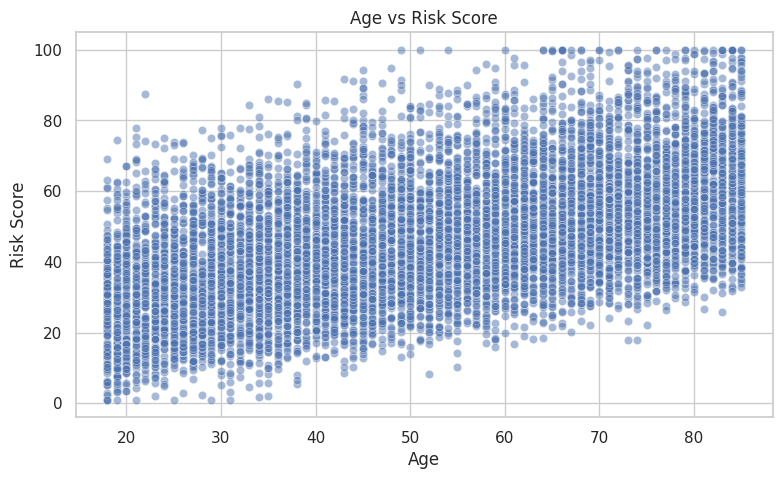

Correlation between Age and Risk Score: 0.5370607035402717


In [6]:
# Age vs Risk Score
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="risk_score",
    alpha=0.5
)

plt.title("Age vs Risk Score")
plt.xlabel("Age")
plt.ylabel("Risk Score")

plt.show()

# calculate correlation
age_risk_corr = df["age"].corr(df["risk_score"])
print("Correlation between Age and Risk Score:", age_risk_corr)

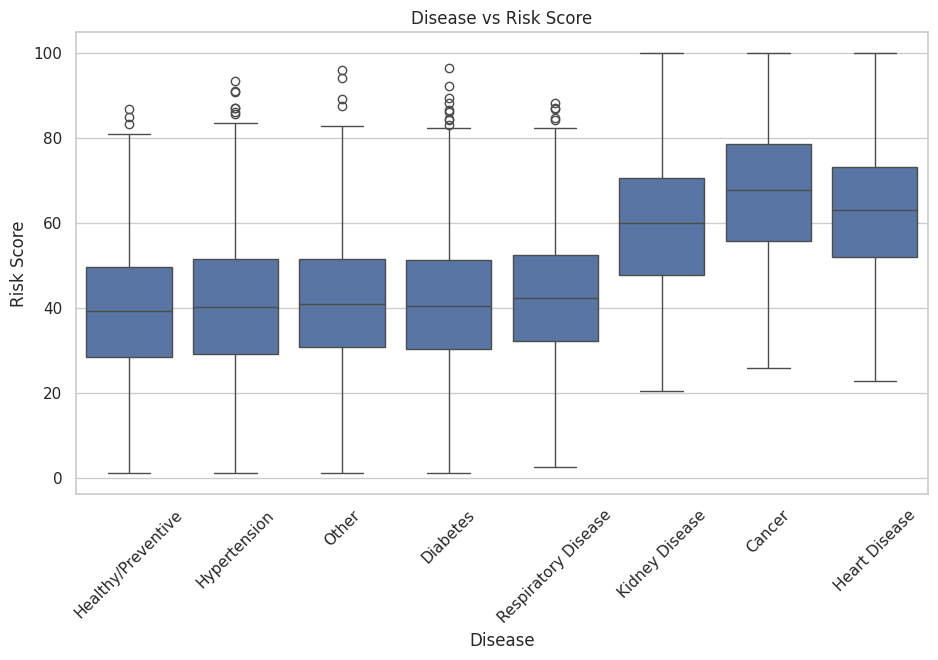

,count,mean,median,min,max
disease,,,,,
Cancer,638,67.864420,67.80,25.7,100.0
Heart Disease,1146,63.226178,63.15,22.7,100.0
Kidney Disease,674,59.619139,59.95,20.4,100.0
Respiratory Disease,1121,42.813559,42.20,2.4,88.3
Other,1131,41.462511,40.80,1.0,96.1
Diabetes,1606,41.178954,40.45,1.0,96.6
Hypertension,1884,40.572824,40.10,1.0,93.5
Healthy/Preventive,1800,39.317500,39.20,1.0,86.8


In [11]:
# Disease vs Risk Score
plt.figure(figsize=(11,6))

sns.boxplot(
    data=df,
    x="disease",
    y="risk_score"
)

plt.title("Disease vs Risk Score")
plt.xlabel("Disease")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)

plt.show()

# disease risk score
disease_risk = (
    df.groupby("disease")["risk_score"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

disease_risk


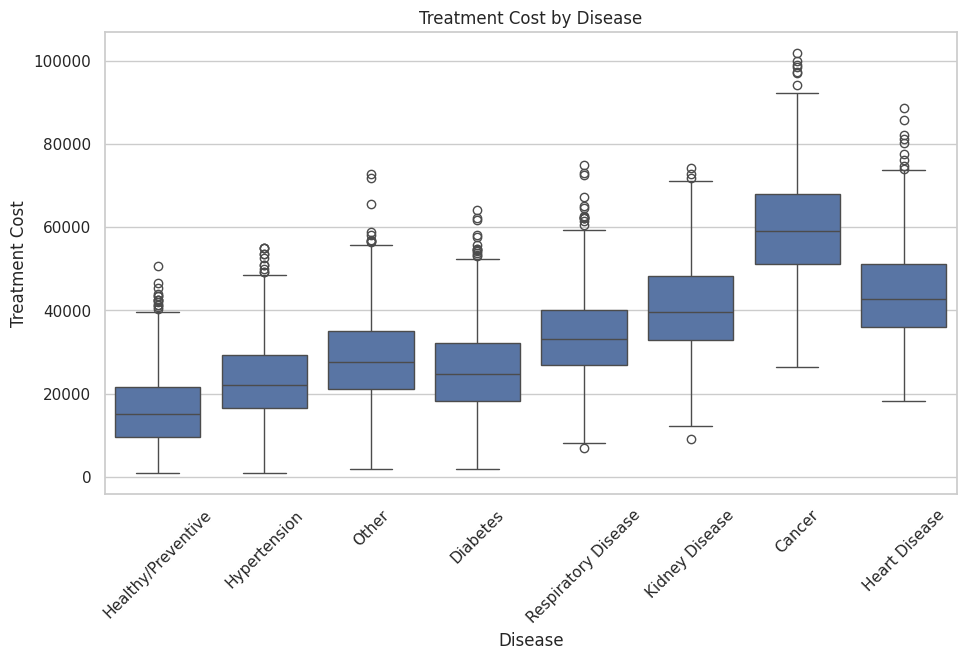

,count,mean,median,min,max
disease,,,,,
Cancer,638,59879.951411,59063.0,26350.0,101926.0
Heart Disease,1146,44144.046248,42745.0,18296.0,88708.0
Kidney Disease,674,40529.280415,39591.5,9168.0,74373.0
Respiratory Disease,1121,33915.394291,33172.0,6860.0,74931.0
Other,1131,28385.069850,27559.0,1778.0,72771.0
Diabetes,1606,25583.110212,24651.0,1906.0,64154.0
Hypertension,1884,23144.032909,22113.5,800.0,55051.0
Healthy/Preventive,1800,15954.054444,14988.5,800.0,50604.0


In [13]:
# disease vs treatment cost
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="disease",
    y="treatment_cost"
)

plt.title("Treatment Cost by Disease")
plt.xlabel("Disease")
plt.ylabel("Treatment Cost")
plt.xticks(rotation=45)

plt.show()

# disease treatment score
disease_cost = (
    df.groupby("disease")["treatment_cost"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

disease_cost

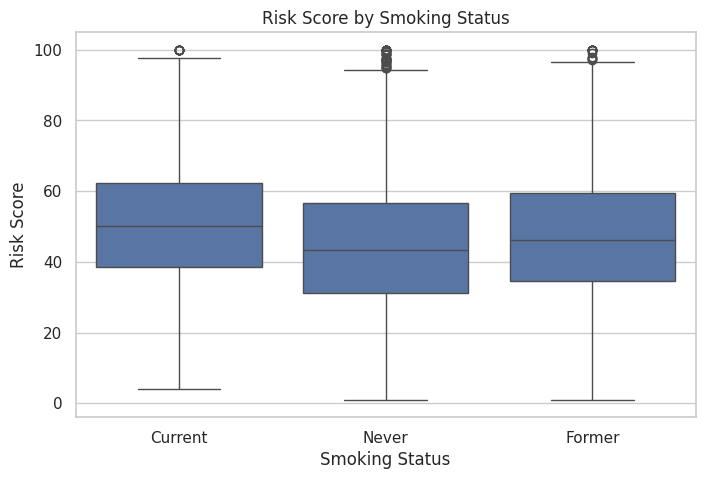

,count,mean,median,min,max
smoking_status,,,,,
Current,1733,51.018003,50.1,4.0,100.0
Former,2464,47.562500,46.2,1.0,100.0
Never,5803,44.556609,43.3,1.0,100.0


In [14]:
# smoking status vs risk score
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="smoking_status",
    y="risk_score"
)

plt.title("Risk Score by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Risk Score")

plt.show()

# smoking ststus risk score
smoking_risk = (
    df.groupby("smoking_status")["risk_score"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

smoking_risk

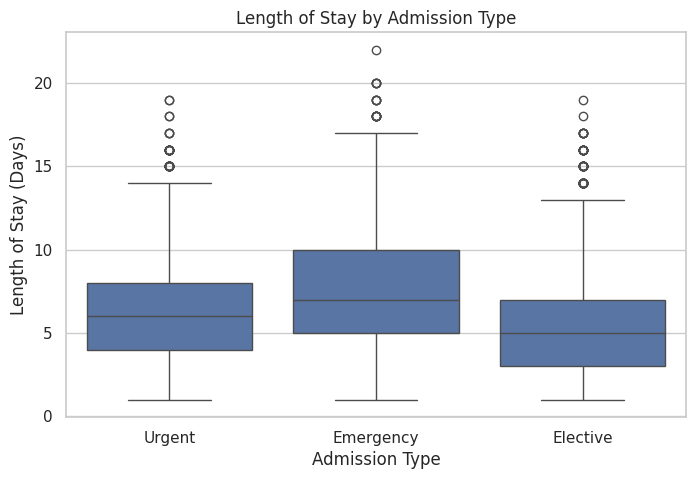

,count,mean,median,min,max
admission_type,,,,,
Emergency,3164,7.595765,7.0,1,22
Urgent,2472,6.649676,6.0,1,19
Elective,4364,5.624427,5.0,1,19


In [18]:
# admission type vs length of stay
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="admission_type",
    y="length_of_stay"
)

plt.title("Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Length of Stay (Days)")

plt.show()

# admission vs length of stay score
admission_los = (
    df.groupby("admission_type")["length_of_stay"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

admission_los


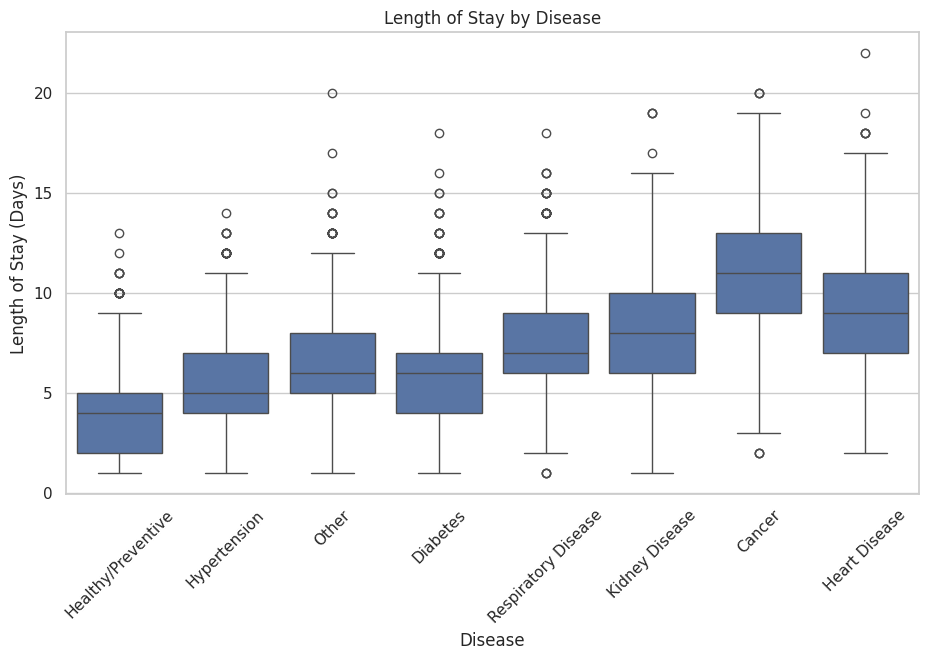

,count,mean,median,min,max
disease,,,,,
Cancer,638,10.982759,11.0,2,20
Heart Disease,1146,8.806283,9.0,2,22
Kidney Disease,674,8.384273,8.0,1,19
Respiratory Disease,1121,7.441570,7.0,1,18
Other,1131,6.475685,6.0,1,20
Diabetes,1606,5.878580,6.0,1,18
Hypertension,1884,5.395966,5.0,1,14
Healthy/Preventive,1800,3.885000,4.0,1,13


In [19]:
# disease vs length of stay
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="disease",
    y="length_of_stay"
)

plt.title("Length of Stay by Disease")
plt.xlabel("Disease")
plt.ylabel("Length of Stay (Days)")
plt.xticks(rotation=45)

plt.show()

# disease length of stay score
disease_los = (
    df.groupby("disease")["length_of_stay"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

disease_los

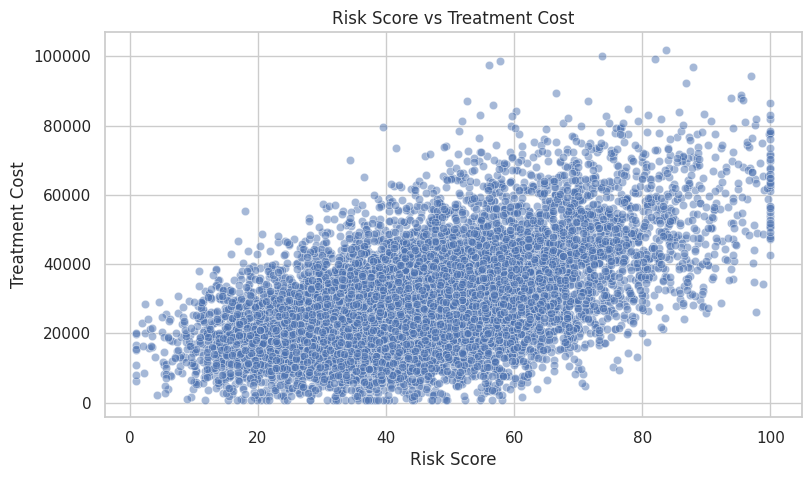

Correlation between Risk Score and Treatment Cost: 0.5565457255381783


In [20]:
# Risk Score vs Treatment Cost
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="risk_score",
    y="treatment_cost",
    alpha=0.5
)

plt.title("Risk Score vs Treatment Cost")
plt.xlabel("Risk Score")
plt.ylabel("Treatment Cost")

plt.show()

# risk treatment score
risk_cost_corr = df["risk_score"].corr(
    df["treatment_cost"]
)

print(
    "Correlation between Risk Score and Treatment Cost:",
    risk_cost_corr
)

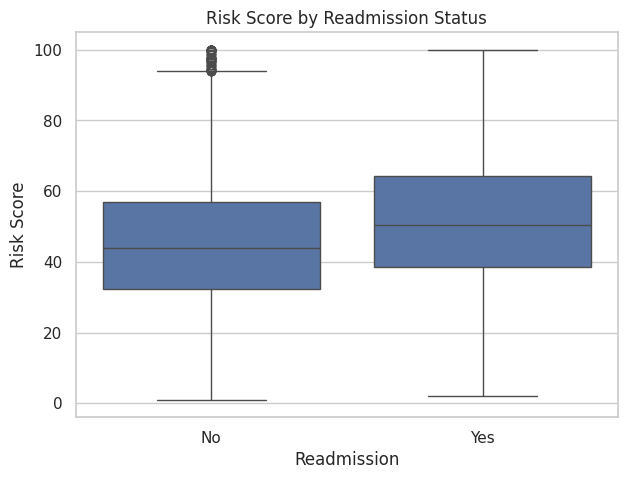

,count,mean,median,min,max
readmission,,,,,
No,7936,45.033140,43.9,1.0,100.0
Yes,2064,51.737984,50.4,2.1,100.0


In [21]:
# Readmission vs Risk Score
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="readmission",
    y="risk_score"
)

plt.title("Risk Score by Readmission Status")
plt.xlabel("Readmission")
plt.ylabel("Risk Score")

plt.show()

# readmission risk score
readmission_risk = (
    df.groupby("readmission")["risk_score"]
    .agg(["count", "mean", "median", "min", "max"])
)

readmission_risk

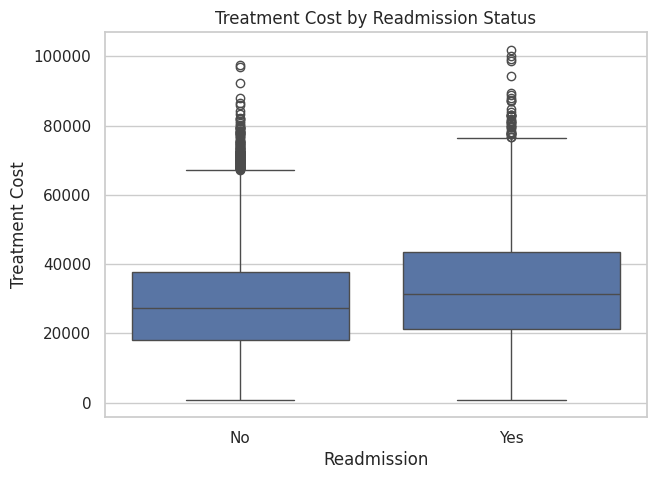

,count,mean,median,min,max
readmission,,,,,
No,7936,28981.478075,27173.5,800.0,97462.0
Yes,2064,33741.285368,31434.0,800.0,101926.0


In [22]:
# Readmission vs Treatment Cost
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="readmission",
    y="treatment_cost"
)

plt.title("Treatment Cost by Readmission Status")
plt.xlabel("Readmission")
plt.ylabel("Treatment Cost")

plt.show()

# readmission treatment cost score
readmission_cost = (
    df.groupby("readmission")["treatment_cost"]
    .agg(["count", "mean", "median", "min", "max"])
)

readmission_cost

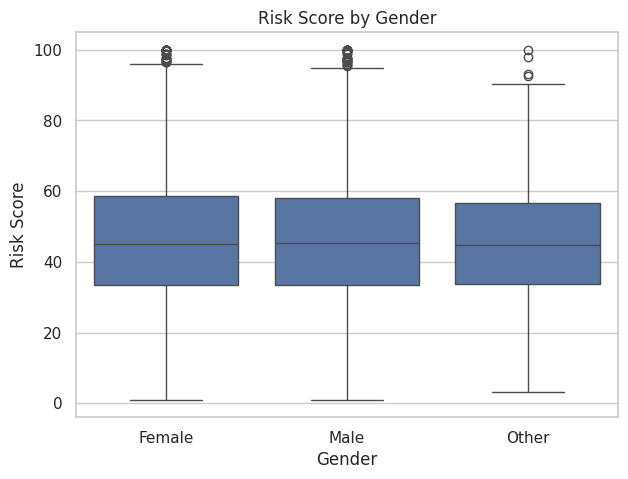

,count,mean,median,min,max
gender,,,,,
Female,4887,46.499079,45.00,1.0,100.0
Male,4927,46.369434,45.30,1.0,100.0
Other,186,45.521505,44.85,3.1,100.0


In [23]:
# gender vs risk score
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="gender",
    y="risk_score"
)

plt.title("Risk Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Risk Score")

plt.show()

# gender risk score cost
gender_risk = (
    df.groupby("gender")["risk_score"]
    .agg(["count", "mean", "median", "min", "max"])
)

gender_risk

In [24]:
# Create a correlation summary
numerical_columns = [
    "age",
    "blood_pressure",
    "heart_rate",
    "bmi",
    "length_of_stay",
    "medication_count",
    "treatment_cost",
    "risk_score"
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,age,blood_pressure,heart_rate,bmi,length_of_stay,medication_count,treatment_cost,risk_score
age,1.000000,-0.011082,-0.006543,-0.000990,-0.003837,0.258895,0.015820,0.537061
blood_pressure,-0.011082,1.000000,0.004432,0.005067,-0.003885,-0.001317,-0.006293,-0.012683
heart_rate,-0.006543,0.004432,1.000000,0.003954,-0.005320,-0.014063,-0.015408,-0.010472
bmi,-0.000990,0.005067,0.003954,1.000000,0.007333,0.146097,0.016495,0.149893
length_of_stay,-0.003837,-0.003885,-0.005320,0.007333,1.000000,0.000686,0.841815,0.475166
medication_count,0.258895,-0.001317,-0.014063,0.146097,0.000686,1.000000,0.082722,0.276955
treatment_cost,0.015820,-0.006293,-0.015408,0.016495,0.841815,0.082722,1.000000,0.556546
risk_score,0.537061,-0.012683,-0.010472,0.149893,0.475166,0.276955,0.556546,1.000000


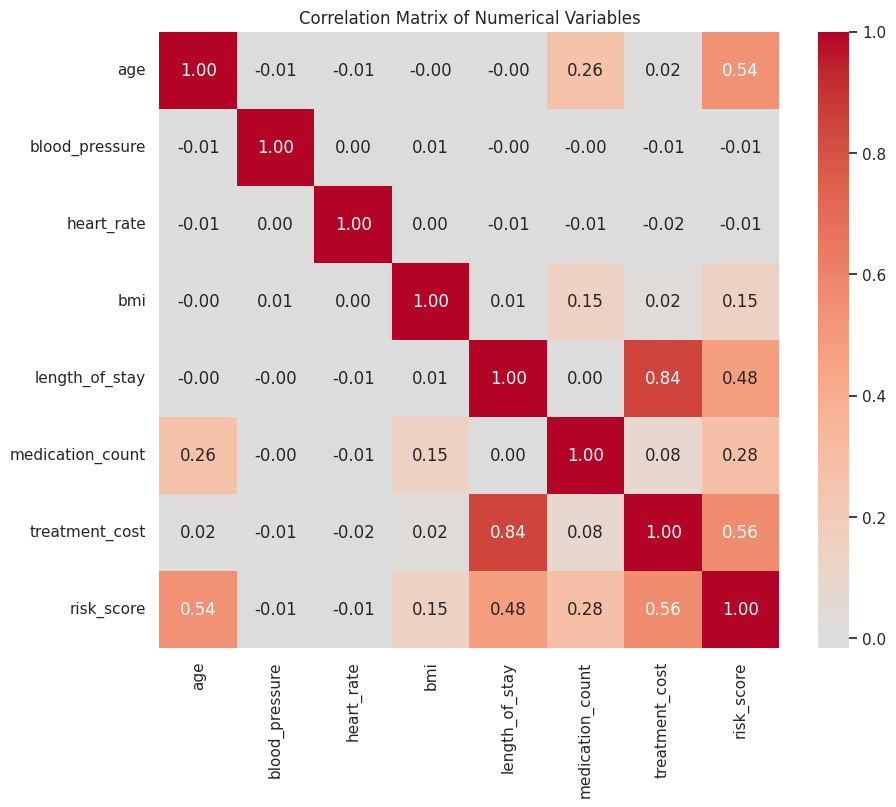

In [25]:
# visualize correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [26]:
# relationship summary table
relationship_summary = pd.DataFrame({
    "Relationship": [
        "Age vs Risk Score",
        "Risk Score vs Treatment Cost"
    ],
    "Correlation": [
        age_risk_corr,
        risk_cost_corr
    ]
})

relationship_summary

,Relationship,Correlation
0,Age vs Risk Score,0.537061
1,Risk Score vs Treatment Cost,0.556546


## Day 7 — Bivariate Analysis Observations

### Age vs Risk Score
- Age and risk score have a correlation of approximately 0.54.
- This indicates a moderate positive linear relationship in the dataset.
- This relationship represents association and does not establish causation.

### Disease vs Risk Score
- Risk scores differ substantially across disease categories.
- Cancer has the highest mean risk score at approximately 67.86.
- Heart Disease and Kidney Disease also have relatively high mean risk scores.
- Healthy/Preventive has the lowest mean risk score at approximately 39.32.

### Disease vs Treatment Cost
- Treatment costs vary substantially across disease categories.
- Cancer has the highest mean treatment cost at approximately ₹59,880.
- Healthy/Preventive has the lowest mean treatment cost at approximately ₹15,954.

### Smoking Status vs Risk Score
- Current smokers have the highest mean risk score at approximately 51.02.
- Former smokers have a mean risk score of approximately 47.56.
- Never smokers have the lowest mean risk score at approximately 44.56.
- This is an observed association and does not establish causation.

### Admission Type vs Length of Stay
- Emergency admissions have the highest average length of stay at approximately 7.60 days.
- Urgent admissions average approximately 6.65 days.
- Elective admissions have the lowest average at approximately 5.62 days.

### Disease vs Length of Stay
- Length of stay varies substantially across disease categories.
- Cancer has the highest mean length of stay at approximately 10.98 days.
- Healthy/Preventive has the lowest mean at approximately 3.89 days.

### Risk Score vs Treatment Cost
- Risk score and treatment cost have a correlation of approximately 0.56.
- This indicates a moderate positive linear relationship in the dataset.
- Higher risk scores tend to be associated with higher treatment costs.

### Readmission vs Risk Score
- Patients with readmission = Yes have a higher mean risk score than patients with readmission = No.
- The mean risk scores are approximately 51.74 and 45.03 respectively.
- The difference is approximately 6.70 points.

### Readmission vs Treatment Cost
- The readmitted group has a higher mean treatment cost than the non-readmitted group.
- Mean treatment costs are approximately ₹33,741 and ₹28,981 respectively.
- The difference is approximately ₹4,760.

### Gender vs Risk Score
- Mean risk scores are similar across gender categories.
- Female patients have a mean risk score of approximately 46.50.
- Male patients have a mean risk score of approximately 46.37.
- Other has a mean risk score of approximately 45.52.

### Overall Findings
- Several healthcare variables show meaningful descriptive relationships with risk score, treatment cost, or length of stay.
- Disease category is associated with substantial differences in observed risk scores, treatment costs, and length of stay.
- Risk score has moderate positive correlations with both age and treatment cost.
- Readmitted patients have higher average risk scores and treatment costs in this dataset.
- These findings identify relationships that can be investigated more deeply in subsequent EDA.